# 範例3. 使用CNN進行物件偵測
### 修改自 [Turning any CNN image classifier into an object detector with Keras, TensorFlow, and OpenCV - PyImageSearch](https://www.pyimagesearch.com/2020/06/22/turning-any-cnn-image-classifier-into-an-object-detector-with-keras-tensorflow-and-opencv/)

## 載入套件

In [1]:
from typing import Iterator, cast

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F
from torchvision import models, transforms

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [3]:
device = "cpu"

In [4]:
# 參數設定
WIDTH = 600  # 圖像縮放為 (600, 600)
PYR_SCALE = 1.5  # 影像金字塔縮放比例
WIN_STEP = 16  # 視窗滑動步數
ROI_SIZE = (250, 250)  # 視窗大小
INPUT_SIZE = (224, 224)  # CNN的輸入尺寸

## 載入 ResNet50 模型

In [5]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)

## 讀取要辨識的圖片

In [6]:
filename = 'images_Object_Detection/bike.jpg'
orig = Image.open(filename)
# 等比例縮放圖片
width_height_ratio = orig.size[1] / orig.size[0]
orig = orig.resize((WIDTH, int(width_height_ratio * WIDTH)))
orig.size

(600, 400)

## 定義滑動視窗與影像金字塔函數

In [7]:
# 滑動視窗函數
def sliding_window(image: Image.Image, step: int, ws: tuple[int, int]) -> Iterator[tuple[int, int, Image.Image]]:
    for y in range(0, image.size[1] - ws[1], step):  # 向下滑動 stepSize 格
        for x in range(0, image.size[0] - ws[0], step):  # 向右滑動 stepSize 格
            # 傳回裁剪後的視窗
            yield (x, y, image.crop((x, y, x + ws[0], y + ws[1])))


# 影像金字塔函數
# image：原圖，scale：每次縮小倍數，minSize：最小尺寸
def image_pyramid(
    image: Image.Image, scale: float = 1.5, minSize: tuple[int, int] = (224, 224)
) -> Iterator[Image.Image]:
    # 第一次傳回原圖
    yield image

    # keep looping over the image pyramid
    while True:
        # 計算縮小後的尺寸
        w = int(image.size[0] / scale)
        image = image.resize((w, int(width_height_ratio * w)))

        # 直到最小尺寸為止
        if image.size[0] < minSize[1] or image.size[1] < minSize[0]:
            break

        # 傳回縮小後的圖像
        yield image

## 定義轉換函數

In [8]:
# 轉換函數
transform = transforms.Compose(
    [
        transforms.Resize(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


# PIL格式轉換為OpenCV格式
def PIL2CV2(orig: Image.Image) -> np.ndarray:
    pil_image = orig.copy()
    open_cv_image = np.array(pil_image)
    return open_cv_image[:, :, ::-1].copy()

## 經由影像金字塔與滑動視窗操作，取得每一個要偵測的視窗

In [9]:
# 產生影像金字塔
pyramid = image_pyramid(orig, scale=PYR_SCALE, minSize=ROI_SIZE)
rois = torch.tensor([])  # 候選框
locs: list[tuple[int, int, int, int]] = []  # 位置
for image in pyramid:
    # 框與原圖的比例
    scale = WIDTH / float(image.size[0])
    print(image.size, 1 / scale)

    # 滑動視窗
    for x, y, roiOrig in sliding_window(image, WIN_STEP, ROI_SIZE):
        # 取得候選框
        x = int(x * scale)
        y = int(y * scale)
        w = int(ROI_SIZE[0] * scale)
        h = int(ROI_SIZE[1] * scale)

        # 縮放圖形以符合模型輸入規格
        roi = cast(torch.Tensor, transform(roiOrig))
        roi = roi.unsqueeze(0)  # 增加一維(筆數)

        # 加入輸出變數中
        if len(rois.shape) == 1:
            rois = roi
        else:
            rois = torch.cat((rois, roi), dim=0)
        locs.append((x, y, x + w, y + h))

rois = rois.to(device)

(600, 400) 1.0
(400, 266) 0.6666666666666666


In [10]:
400 / 1.5

266.6666666666667

In [11]:
print(locs)

[(0, 0, 250, 250), (16, 0, 266, 250), (32, 0, 282, 250), (48, 0, 298, 250), (64, 0, 314, 250), (80, 0, 330, 250), (96, 0, 346, 250), (112, 0, 362, 250), (128, 0, 378, 250), (144, 0, 394, 250), (160, 0, 410, 250), (176, 0, 426, 250), (192, 0, 442, 250), (208, 0, 458, 250), (224, 0, 474, 250), (240, 0, 490, 250), (256, 0, 506, 250), (272, 0, 522, 250), (288, 0, 538, 250), (304, 0, 554, 250), (320, 0, 570, 250), (336, 0, 586, 250), (0, 16, 250, 266), (16, 16, 266, 266), (32, 16, 282, 266), (48, 16, 298, 266), (64, 16, 314, 266), (80, 16, 330, 266), (96, 16, 346, 266), (112, 16, 362, 266), (128, 16, 378, 266), (144, 16, 394, 266), (160, 16, 410, 266), (176, 16, 426, 266), (192, 16, 442, 266), (208, 16, 458, 266), (224, 16, 474, 266), (240, 16, 490, 266), (256, 16, 506, 266), (272, 16, 522, 266), (288, 16, 538, 266), (304, 16, 554, 266), (320, 16, 570, 266), (336, 16, 586, 266), (0, 32, 250, 282), (16, 32, 266, 282), (32, 32, 282, 282), (48, 32, 298, 282), (64, 32, 314, 282), (80, 32, 330, 

In [12]:
rois.shape

torch.Size([230, 3, 224, 224])

## 預測

In [13]:
# 讀取類別列表
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# 預測
model.eval()
with torch.no_grad():
    output = model(rois)

# 轉成機率
probabilities = F.softmax(output, dim=1)

# 取得第一名
top_prob, top_catid = torch.topk(probabilities, 1)
probabilities

tensor([[1.6771e-04, 5.2512e-04, 9.2252e-05,  ..., 1.8170e-04, 1.6741e-04,
         7.3641e-04],
        [1.2127e-04, 4.0614e-04, 7.2401e-05,  ..., 1.3768e-04, 1.4120e-04,
         5.8518e-04],
        [1.6428e-04, 5.2675e-04, 1.0212e-04,  ..., 1.8108e-04, 1.7792e-04,
         8.1742e-04],
        ...,
        [3.1098e-04, 6.8980e-04, 2.2177e-04,  ..., 4.0997e-04, 3.7230e-04,
         1.3851e-03],
        [3.6965e-04, 7.8874e-04, 2.6550e-04,  ..., 4.4434e-04, 4.5010e-04,
         1.5273e-03],
        [3.9275e-04, 8.1304e-04, 2.5488e-04,  ..., 4.7998e-04, 4.3684e-04,
         1.3687e-03]])

In [14]:
probabilities[0, 518]

tensor(0.1499)

In [15]:
torch.topk(probabilities[202], 1)

torch.return_types.topk(
values=tensor([0.3564]),
indices=tensor([518]))

In [16]:
top_catid.numpy().reshape(-1)

array([671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       444, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 518, 518, 671, 671, 518, 518, 518, 518, 518, 518, 671, 671,
       671, 671, 671, 671, 518, 671, 671, 518, 671, 671, 518, 518, 518,
       518, 518, 518, 671, 671, 671, 671, 671, 671, 671, 671, 671, 671,
       671, 671, 671, 671, 518, 518, 518, 518, 518, 518, 518, 518, 518,
       518, 518, 518, 671, 518, 671, 518, 671, 671, 671, 671, 518, 518,
       518, 518, 518, 518, 518, 518, 518, 518, 518, 518, 518, 518, 518,
       518, 518, 671, 671, 671, 671, 518, 671, 518, 518, 518, 51

In [17]:
for i in range(probabilities.shape[0]):
    print(i, probabilities[i, 671].item())

0 0.4013267755508423
1 0.44094201922416687
2 0.3349531888961792
3 0.4240530729293823
4 0.4855506420135498
5 0.6326646208763123
6 0.604781448841095
7 0.4066457748413086
8 0.23254935443401337
9 0.35318052768707275
10 0.30150195956230164
11 0.34631016850471497
12 0.3986503481864929
13 0.34012535214424133
14 0.39173200726509094
15 0.4281245768070221
16 0.4729112684726715
17 0.3673068881034851
18 0.4542422890663147
19 0.3851816654205322
20 0.37338826060295105
21 0.4633418619632721
22 0.41798341274261475
23 0.3841922879219055
24 0.30359068512916565
25 0.31398358941078186
26 0.22050955891609192
27 0.5193129181861877
28 0.6156536936759949
29 0.4818492531776428
30 0.3054625391960144
31 0.40577200055122375
32 0.3590248227119446
33 0.3415522277355194
34 0.37289875745773315
35 0.39705610275268555
36 0.47610580921173096
37 0.525337815284729
38 0.5569015741348267
39 0.5020275115966797
40 0.6069516539573669
41 0.4398241639137268
42 0.43967050313949585
43 0.4045390486717224
44 0.4715859293937683
45 0.

## 檢查預測結果，辨識機率須大於設定值

In [18]:
MIN_CONFIDENCE = 0.4  # 辨識機率門檻值

labels: dict[str, list] = {}
for i, p in enumerate(zip(top_prob.numpy().reshape(-1), top_catid.numpy().reshape(-1))):
    prob, imagenetID = p
    label = categories[imagenetID]

    # 機率大於設定值，則放入候選名單
    if prob >= MIN_CONFIDENCE:
        # 只偵測自行車(671)
        if imagenetID != 671:
            continue  # bike
        # 放入候選名單
        box = locs[i]
        L = labels.get(label, [])
        L.append((box, prob))
        labels[label] = L

labels.keys()

dict_keys(['mountain bike'])

In [19]:
labels['mountain bike']

[((0, 0, 250, 250), np.float32(0.40132678)),
 ((16, 0, 266, 250), np.float32(0.44094202)),
 ((48, 0, 298, 250), np.float32(0.42405307)),
 ((64, 0, 314, 250), np.float32(0.48555064)),
 ((80, 0, 330, 250), np.float32(0.6326646)),
 ((96, 0, 346, 250), np.float32(0.60478145)),
 ((112, 0, 362, 250), np.float32(0.40664577)),
 ((240, 0, 490, 250), np.float32(0.42812458)),
 ((256, 0, 506, 250), np.float32(0.47291127)),
 ((288, 0, 538, 250), np.float32(0.4542423)),
 ((336, 0, 586, 250), np.float32(0.46334186)),
 ((0, 16, 250, 266), np.float32(0.4179834)),
 ((80, 16, 330, 266), np.float32(0.5193129)),
 ((96, 16, 346, 266), np.float32(0.6156537)),
 ((112, 16, 362, 266), np.float32(0.48184925)),
 ((144, 16, 394, 266), np.float32(0.405772)),
 ((224, 16, 474, 266), np.float32(0.4761058)),
 ((240, 16, 490, 266), np.float32(0.5253378)),
 ((256, 16, 506, 266), np.float32(0.5569016)),
 ((272, 16, 522, 266), np.float32(0.5020275)),
 ((288, 16, 538, 266), np.float32(0.60695165)),
 ((304, 16, 554, 266), np

## 定義NMS函數

In [20]:
# https://learnopencv.com/non-maximum-suppression-theory-and-implementation-in-pytorch/
def nms_pytorch(P: torch.Tensor, thresh_iou: float) -> list[torch.Tensor]:
    # we extract coordinates for every
    # prediction box present in P
    x1 = P[:, 0]
    y1 = P[:, 1]
    x2 = P[:, 2]
    y2 = P[:, 3]

    # we extract the confidence scores as well
    scores = P[:, 4]

    # calculate area of every block in P
    areas = (x2 - x1) * (y2 - y1)

    # sort the prediction boxes in P
    # according to their confidence scores
    order = scores.argsort()

    # initialise an empty list for
    # filtered prediction boxes
    keep = []

    while len(order) > 0:

        # extract the index of the
        # prediction with highest score
        # we call this prediction S
        idx = order[-1]

        # push S in filtered predictions list
        keep.append(P[idx])

        # remove S from P
        order = order[:-1]

        # sanity check
        if len(order) == 0:
            break

        # select coordinates of BBoxes according to
        # the indices in order
        xx1 = torch.index_select(x1, dim=0, index=order)
        xx2 = torch.index_select(x2, dim=0, index=order)
        yy1 = torch.index_select(y1, dim=0, index=order)
        yy2 = torch.index_select(y2, dim=0, index=order)

        # find the coordinates of the intersection boxes
        xx1 = torch.max(xx1, x1[idx])
        yy1 = torch.max(yy1, y1[idx])
        xx2 = torch.min(xx2, x2[idx])
        yy2 = torch.min(yy2, y2[idx])

        # find height and width of the intersection boxes
        w = xx2 - xx1
        h = yy2 - yy1

        # take max with 0.0 to avoid negative w and h
        # due to non-overlapping boxes
        w = torch.clamp(w, min=0.0)
        h = torch.clamp(h, min=0.0)

        # find the intersection area
        inter = w * h

        # find the areas of BBoxes according the indices in order
        rem_areas = torch.index_select(areas, dim=0, index=order)

        # find the union of every prediction T in P
        # with the prediction S
        # Note that areas[idx] represents area of S
        union = (rem_areas - inter) + areas[idx]

        # find the IoU of every prediction in P with S
        IoU = inter / union

        # keep the boxes with IoU less than thresh_iou
        mask = IoU < thresh_iou
        order = order[mask]

    return keep

In [21]:
def non_max_suppression_slow(boxes: np.ndarray, overlapThresh: float = 0.5) -> np.ndarray | list:
    if len(boxes) == 0:
        return []

    pick = []  # 儲存篩選的結果
    x1 = boxes[:, 0]  # 取得候選的視窗的左/上/右/下 座標
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    # 計算候選視窗的面積
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)  # 依視窗的底Y座標排序

    # 比對重疊比例
    while len(idxs) > 0:
        # 最後一筆
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        suppress = [last]

        # 比對最後一筆與其他視窗重疊的比例
        for pos in range(0, last):
            j = idxs[pos]

            # 取得所有視窗的涵蓋範圍
            xx1 = max(x1[i], x1[j])
            yy1 = max(y1[i], y1[j])
            xx2 = min(x2[i], x2[j])
            yy2 = min(y2[i], y2[j])
            w = max(0, xx2 - xx1 + 1)
            h = max(0, yy2 - yy1 + 1)

            # 計算重疊比例
            overlap = float(w * h) / area[j]

            # 如果大於門檻值，則儲存起來
            if overlap > overlapThresh:
                suppress.append(pos)

        # 刪除合格的視窗，繼續比對
        idxs = np.delete(idxs, suppress)

    # 傳回合格的視窗
    return boxes[pick]

## 進行 NMS，並對偵測到的物件畫框

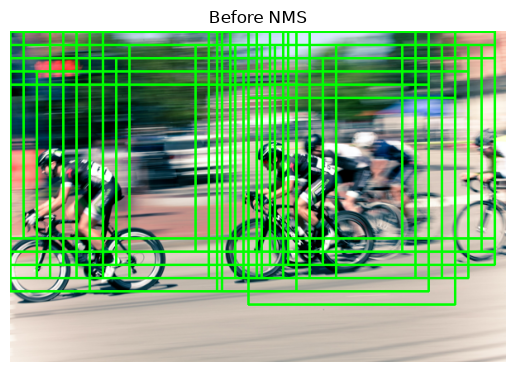

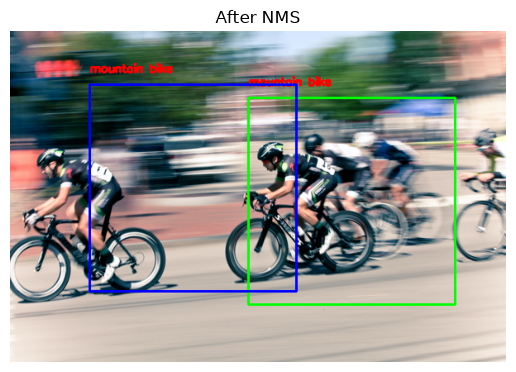

In [22]:
# 掃描每一個類別
for label in labels.keys():
    # if label != categories[671]: continue # bike

    # 複製原圖
    open_cv_image = PIL2CV2(orig)

    # 畫框
    for box, prob in labels[label]:
        startX, startY, endX, endY = box
        cv2.rectangle(open_cv_image, (startX, startY), (endX, endY), (0, 255, 0), 2)

    # 顯示 NMS(non-maxima suppression) 前的框
    plt.imshow(cv2.cvtColor(open_cv_image, cv2.COLOR_BGR2RGB))
    plt.title("Before NMS")
    plt.axis("off")
    plt.show()

    # NMS
    open_cv_image2 = PIL2CV2(orig)
    boxes = np.array([p[0] for p in labels[label]])
    proba = np.array([p[1] for p in labels[label]])
    # print(boxes.shape, proba.shape)
    # boxes = nms_pytorch(torch.cat((torch.tensor(boxes),
    #    torch.tensor(proba).reshape(proba.shape[0], -1)), dim=1) ,
    #    MIN_CONFIDENCE) # non max suppression
    boxes = non_max_suppression_slow(boxes, MIN_CONFIDENCE)  # non max suppression

    color_list = [(0, 255, 0), (255, 0, 0), (255, 255, 0), (0, 0, 0), (0, 255, 255)]
    for i, x in enumerate(boxes):
        # startX, startY, endX, endY, label = x.numpy()
        startX, startY, endX, endY = x  # .numpy()
        # 畫框及類別
        cv2.rectangle(
            open_cv_image2, (int(startX), int(startY)), (int(endX), int(endY)), color_list[i % len(color_list)], 2
        )
        startY = startY - 15 if startY - 15 > 0 else startY + 15
        cv2.putText(
            open_cv_image2, str(label), (int(startX), int(startY)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2
        )

    # 顯示
    plt.imshow(cv2.cvtColor(open_cv_image2, cv2.COLOR_BGR2RGB))
    plt.title("After NMS")
    plt.axis("off")
    plt.show()

In [23]:
boxes

array([[288,  80, 538, 330],
       [ 96,  64, 346, 314]])